In [25]:
import pandas as pd
import joblib

from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from category_encoders import BinaryEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV

df = pd.read_csv(r"C:\Users\Asus\Desktop\Projects\Dataset\cleaned_student_data.csv")

x = df.drop(columns=['student_id','final_exam_score','final_grade'])
y = df['final_exam_score']

x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)

num_columns = ['study_time_hours','attendance_percent','sleep_hours','previous_grade']
ord_columns = ['parental_education']
nom_columns = ['gender']
bool_columns = ['internet_access','extracurricular_activities','part_time_job']

education_order = ['High School','Bachelors','Masters','PhD']

preprocessor = ColumnTransformer(
    transformers=[
        ('num_scaled',StandardScaler(),num_columns),
        ('ord_encoded',OrdinalEncoder(categories=[education_order]),ord_columns),
        ('nom_encoded',BinaryEncoder(),nom_columns)
    ],remainder='passthrough'
)

pipe = Pipeline(
    steps=[
        ('preprocessing',preprocessor),
        ('regressor',KNeighborsRegressor())
    ]
)

params = {
    'regressor__n_neighbors': [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30, 40, 50],
    'regressor__weights': ['uniform', 'distance'],
    'regressor__p': [1, 2],
    'regressor__leaf_size': [10, 20, 30, 40, 50]
}


In [26]:
grid_model = GridSearchCV(pipe,param_grid=params,cv=10,scoring='neg_mean_squared_error',n_jobs=-1,verbose=1)
grid_model.fit(x_train,y_train)

best_model = grid_model.best_estimator_

y_pred = best_model.predict(x_test)


Fitting 10 folds for each of 320 candidates, totalling 3200 fits


In [27]:
r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)

scores = {
    'r2':r2,
    'mae':mae,
    'rmse':rmse
}

print(scores)

{'r2': 0.5316198823215068, 'mae': 5.6625, 'rmse': 7.100352874153509}


In [18]:
import pandas as pd
import joblib

from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from category_encoders import BinaryEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

df = pd.read_csv(r"C:\Users\Asus\Desktop\Projects\Dataset\cleaned_student_data.csv")

x = df.drop(columns=['student_id','final_exam_score','final_grade'])
y = df['final_exam_score']

x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)

num_columns = ['study_time_hours','attendance_percent','sleep_hours','previous_grade']
ord_columns = ['parental_education']
nom_columns = ['gender']
bool_columns = ['internet_access','extracurricular_activities','part_time_job','Pass']

education_order = ['High School','Bachelors','Masters','PhD']

preprocessor = ColumnTransformer(
    transformers=[
        ('num_scaled',StandardScaler(),num_columns),
        ('ord_encoded',OrdinalEncoder(categories=[education_order]),ord_columns),
        ('nom_encoded',BinaryEncoder(),nom_columns)
    ],remainder='passthrough'
)

pipe = Pipeline(
    steps=[
        ('preprocessing',preprocessor),
        ('regressor',Lasso(max_iter=10000))
    ]
)

params = {
    'regressor__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}


In [22]:
grid_model = GridSearchCV(pipe,param_grid=params,cv=10,scoring='accuracy',n_jobs=-1,verbose=1)
grid_model.fit(x_train,y_train)

best_model = grid_model.best_estimator_


Fitting 10 folds for each of 6 candidates, totalling 60 fits


C:\Users\Asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan]
  warnings.warn(


In [23]:

y_pred = best_model.predict(x_test)

r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)

scores = {
    'r2':r2,
    'mae':mae,
    'rmse':rmse
}

In [24]:
scores


{'r2': 0.6189326714670038, 'mae': 4.971740280125674, 'rmse': 6.40444595115077}

In [ ]:
s

In [28]:
import pandas as pd
import joblib

from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from category_encoders import BinaryEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

df = pd.read_csv(r'C:\Users\Asus\Desktop\Projects\Dataset\cleaned_student_data.csv')

x = df.drop(columns=['student_id','final_exam_score','final_grade'])
y = df['final_exam_score']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

num_columns = ['study_time_hours','attendance_percent','sleep_hours','previous_grade']
ord_columns = ['parental_education']
nom_columns = ['gender']
bool_columns = ['internet_access','extracurricular_activities','part_time_job','Pass']

education_order = ['High School','Bachelors','Masters','PhD']

preprocessor = ColumnTransformer(
    transformers=[
        ('num_scaled',StandardScaler(),num_columns),
        ('ord_encoded',OrdinalEncoder(categories=[education_order]),ord_columns),
        ('nom_encoded',BinaryEncoder(),nom_columns)
    ],remainder='passthrough'
)

pipe = Pipeline(
    steps=[
        ('preprocessing',preprocessor),
        ('regressor',SVR())
    ]
)

params = {
    'regressor__C': [0.01, 0.1, 1, 10, 50, 100, 500, 1000, 5000, 10000],
    'regressor__epsilon': [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1],
    'regressor__gamma': ['scale', 'auto', 0.0001, 0.001, 0.01, 0.05, 0.1, 0.5],
    'regressor__kernel': ['rbf', 'linear']
}


In [ ]:
grid_model = GridSearchCV(pipe,param_grid=params,cv=10,scoring='accuracy',n_jobs=-1,verbose=1)
grid_model.fit(x_train,y_train)

best_model = grid_model.best_estimator_


Fitting 10 folds for each of 1120 candidates, totalling 11200 fits


In [ ]:

y_pred = best_model.predict(x_test)

r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)

scores = {
    'r2':r2,
    'mae':mae,
    'rmse':rmse
}

scores

In [7]:
import pandas as pd
import joblib

from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from category_encoders import BinaryEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

df = pd.read_csv(r'C:\Users\Asus\Desktop\Projects\Dataset\cleaned_student_data.csv')

x = df.drop(columns=['student_id','final_exam_score','final_grade'])
y = df['final_exam_score']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

num_columns = ['study_time_hours','attendance_percent','sleep_hours','previous_grade']
ord_columns = ['parental_education']
nom_columns = ['gender']
bool_columns = ['internet_access','extracurricular_activities','part_time_job','Pass']

education_order = ['High School','Bachelors','Masters','PhD']

preprocessor = ColumnTransformer(
    transformers=[
        ('num_scaled',StandardScaler(),num_columns),
        ('ord_encoded',OrdinalEncoder(categories=[education_order]),ord_columns),
        ('nom_encoded',BinaryEncoder(),nom_columns)
    ],remainder='passthrough'
)

pipe = Pipeline(
    steps=[
        ('preprocessing',preprocessor),
        ('regressor',RandomForestRegressor(random_state=42))
    ]
)

params = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2]
}

In [8]:

grid_model = GridSearchCV(pipe,param_grid=params,cv=10,scoring='r2',n_jobs=-1)
grid_model.fit(x_train,y_train)

best_model = grid_model.best_estimator_

In [9]:
y_pred=best_model.predict(x_test)

r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)

scores = {
    'r2':r2,
    'mae':mae,
    'rmse':rmse
}

scores

{'r2': 0.5816530039761136, 'mae': 5.179231633364497, 'rmse': 6.710409669749119}

In [10]:
features = [
    'study_time_hours',
    'attendance_percent',
    'sleep_hours',
    'previous_grade'
]

for feature in features:
    correlation = df[feature].corr(df['final_exam_score'])
    print(feature, round(correlation, 3))

study_time_hours 0.568
attendance_percent 0.262
sleep_hours 0.148
previous_grade 0.406


In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Users\Asus\Desktop\Projects\Dataset\cleaned_student_data.csv')

df.sample(5)

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
400,401,Female,4.8,81.9,5.9,Bachelors,True,False,True,60.6,85.2,B
767,768,Female,1.5,87.3,6.4,High School,True,True,True,57.3,71.2,C
238,239,Male,5.9,100.0,7.3,Bachelors,True,True,False,89.8,100.0,A
38,39,Male,4.5,74.6,5.0,High School,True,True,True,72.6,89.5,B
245,246,Female,5.8,76.5,7.4,Bachelors,True,True,False,79.9,100.0,A


In [2]:
df.isna().sum()

student_id                    0
gender                        0
study_time_hours              0
attendance_percent            0
sleep_hours                   0
parental_education            0
internet_access               0
extracurricular_activities    0
part_time_job                 0
previous_grade                0
final_exam_score              0
final_grade                   0
dtype: int64

In [5]:
df.groupby('gender')['final_exam_score'].mean()

gender
Female    83.606863
Male      83.477551
Name: final_exam_score, dtype: float64

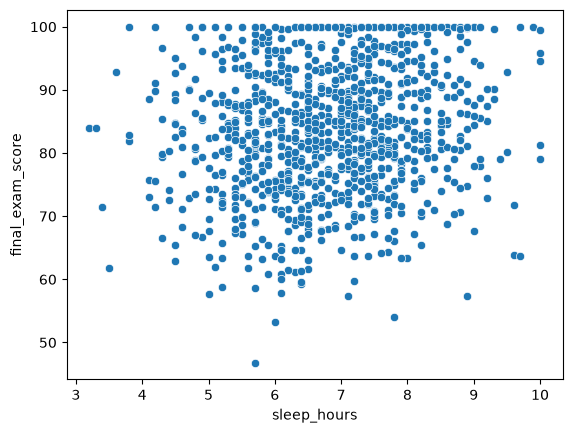

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

fig,ax = plt.subplots()
# sns.scatterplot(df,y='final_exam_score',x='attendance_percent',ax=ax)
# plt.show()
sns.scatterplot(df,y='final_exam_score',x='sleep_hours',ax=ax)
plt.show()

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Asus\Desktop\Projects\Dataset\cleaned_student_data.csv")

df.sample(10)

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
23,24,Female,4.3,82.5,5.4,PhD,False,True,False,61.0,71.2,C
350,351,Female,3.9,74.5,6.4,Masters,True,False,False,72.2,75.3,C
290,291,Male,1.8,97.2,7.2,Bachelors,True,False,False,93.9,94.9,A
929,930,Male,1.5,89.2,7.3,High School,True,False,False,53.8,80.8,B
302,303,Male,4.6,87.8,7.7,Bachelors,True,True,False,56.2,91.0,A
805,806,Female,1.5,89.6,7.7,Bachelors,True,False,False,73.6,82.1,B
347,348,Female,0.9,82.0,5.7,Masters,True,False,False,61.2,69.0,D
591,592,Female,0.5,94.5,5.8,Bachelors,True,True,False,59.9,63.2,D
788,789,Female,2.4,76.6,5.6,Bachelors,True,False,False,74.3,72.1,C
904,905,Male,4.1,100.0,8.5,High School,True,False,False,64.6,90.8,A


In [6]:
df['study_sleep_ratio'] = df['study_time_hours']/(df['sleep_hours']+1)
df['study_attendance'] = df['study_time_hours']*df['attendance_percent']
df.sample(5)

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade,study_sleep_ratio,study_attendance
785,786,Male,3.9,84.2,7.5,Bachelors,True,True,True,88.5,97.0,A,0.458824,328.38
153,154,Male,2.6,56.3,6.9,Bachelors,False,True,False,69.4,75.7,C,0.329114,146.38
22,23,Female,3.7,81.8,7.8,High School,False,False,False,74.8,73.4,C,0.420455,302.66
214,215,Male,4.6,83.2,4.5,Bachelors,True,True,False,58.0,84.7,B,0.836364,382.72
448,449,Male,3.4,78.9,6.5,Bachelors,True,True,False,88.7,90.7,A,0.453333,268.26


In [7]:
test_df = df.to_csv('test_df.csv')

In [8]:
import pandas as pd
import joblib

from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from category_encoders import BinaryEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

df = pd.read_csv(r"C:\Users\Asus\Desktop\Projects\test_df.csv")

x = df.drop(columns=['student_id','final_exam_score','final_grade'])
y = df['final_exam_score']

x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)

num_columns = [
    'study_time_hours',
    'attendance_percent',
    'sleep_hours',
    'previous_grade',
    'study_sleep_ratio'
]
ord_columns = ['parental_education']
nom_columns = ['gender']
bool_columns = ['internet_access','extracurricular_activities','part_time_job','Pass']

education_order = ['High School','Bachelors','Masters','PhD']

preprocessor = ColumnTransformer(
    transformers=[
        ('num_scaled',StandardScaler(),num_columns),
        ('ord_encoded',OrdinalEncoder(categories=[education_order]),ord_columns),
        ('nom_encoded',BinaryEncoder(),nom_columns)
    ],remainder='passthrough'
)

pipe = Pipeline(
    steps=[
        ('preprocessing',preprocessor),
        ('regressor',Lasso(max_iter=10000))
    ]
)

params = {
    'regressor__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}


In [9]:

grid_model = GridSearchCV(pipe,param_grid=params,cv=10,scoring='r2',n_jobs=-1)
grid_model.fit(x_train,y_train)

best_model = grid_model.best_estimator_

In [10]:
y_pred=best_model.predict(x_test)

r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)

scores = {
    'r2':r2,
    'mae':mae,
    'rmse':rmse
}

scores

{'r2': 0.6126050386145812, 'mae': 5.011108311612337, 'rmse': 6.4574000256454}

In [13]:
import pandas as pd
import joblib

from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from category_encoders import BinaryEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

df = pd.read_csv(r'C:\Users\Asus\Desktop\Projects\test_df.csv')

x = df.drop(columns=['student_id','final_exam_score','final_grade'])
y = df['final_exam_score']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

num_columns = [
    'study_time_hours',
    'attendance_percent',
    'sleep_hours',
    'previous_grade',
    'study_sleep_ratio'
]
ord_columns = ['parental_education']
nom_columns = ['gender']
bool_columns = ['internet_access','extracurricular_activities','part_time_job']

education_order = ['High School','Bachelors','Masters','PhD']

preprocessor = ColumnTransformer(
    transformers=[
        ('num_scaled',StandardScaler(),num_columns),
        ('ord_encoded',OrdinalEncoder(categories=[education_order]),ord_columns),
        ('nom_encoded',BinaryEncoder(),nom_columns)
    ],remainder='passthrough'
)

pipe = Pipeline(
    steps=[
        ('preprocessing',preprocessor),
        ('regressor',SVR())
    ]
)

params = {
    'regressor__C': [0.01, 0.1, 1, 10, 50, 100, 500, 1000, 5000, 10000],
    'regressor__epsilon': [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1],
    'regressor__gamma': ['scale', 'auto', 0.0001, 0.001, 0.01, 0.05, 0.1, 0.5],
    'regressor__kernel': ['rbf', 'linear']
}


grid_model = GridSearchCV(pipe,param_grid=params,cv=10,scoring='r2',n_jobs=-1)
grid_model.fit(x_train,y_train)

best_model = grid_model.best_estimator_

y_pred=best_model.predict(x_test)

r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)

scores = {
    'r2':r2,
    'mae':mae,
    'rmse':rmse
}

scores

KeyboardInterrupt: 